In [1]:
# Import libraries
import os
SEED = 42

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
!pip install torchview
from torchview import draw_graph

# Configurazione di TensorBoard e directory
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import requests
from io import BytesIO

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

import cv2
import pandas as pd
from glob import glob
from tqdm import tqdm

2025-12-06 09:01:38.723944: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765011698.928701      87 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765011698.989323      87 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

PyTorch version: 2.6.0+cu124
Device: cuda


THE CODE DOES NOT ELIMINATE SHREK. TOO MANY FALSE NEGATIVES AND FALSE POSITIVES.
first I tried to remove all images with more than 30% of green, it was too much, then the upper bound was 25% and it does not detect Shrek. One kind of pictures is more green, another one is more yellow.
By the end i switched to detecting the images without magenta/ pink/ red since Shrek does not have it, but did not run the code.

while I was waiting, I manually found most of the Shrek.

In [2]:
SHREK_INDICES = {
    104, 112, 130, 147, 173, 189, 193, 203, 213, 218, 228, 237, 249, 250, 
    264, 269, 271, 290, 291, 308, 322, 328, 336, 342, 348, 357, 365, 368, 
    370, 379, 386, 391, 394, 404, 406, 413, 418, 422, 426, 430, 438, 446, 
    447, 454, 456, 469, 478, 481, 487, 492, 495, 505, 509, 514, 520, 527, 
    529, 536, 555, 574, 586, 589, 594, 606, 608, 629, 631, 648, 653, 655, 
    665, 673, 681, 703, 731, 733, 735, 748, 753, 758, 767, 771, 800, 813, 
    819, 825, 826, 832, 846, 868, 903, 919, 930, 936, 937, 958, 960, 1035, 
    1037, 1046, 1062, 1114, 1124, 1125, 1133, 1146, 1150, 1156, 1177, 1184, 
    1186, 1192, 1206, 1212, 1217, 1220, 1229, 1236, 1241, 1245, 1258, 1261, 
    1263, 1274, 1277, 1280, 1281, 1298, 1317, 1335, 1340, 1381, 1385, 1389
}

In [3]:
class Config:
    SEED = 42
    DATA_ROOT = "../input/datasetch2/"

    # The directory where the extracted files will go
    EXTRACT_DIR = DATA_ROOT
    
    PERMANENT_CLEAN_DIR = './clean_processed_data' 
    CLEAN_CSV_PATH = './clean_processed_data.csv'
    TRAIN_LABELS_CSV = os.path.join(EXTRACT_DIR, 'train_labels.csv') 
     
    
    # HSV Ranges for "Green/Yellow" artifacts (Shrek/Goo)
    # H&E is Pink/Purple. This range targets contamination.
    LOWER_GREEN = np.array([35, 60, 60]) # H=15 (more yellow), S=10 (less saturated/more gray), V=10 (darker)
    UPPER_GREEN = np.array([85, 255, 255]) # H=110 (more cyan-green)
    
    # NEW: Explicit label mapping for molecular subtypes
    LABEL_MAP = {
        'Luminal A': 0,
        'Luminal B': 1,
        'HER2': 2,
        'Triple': 3
    }


def seed_everything(seed):
    """Sets deterministic behavior across libraries."""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

# REMOVE SHREK&GOO

In [4]:
def tissue_mask_lab(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    L, A, B = lab[:,:,0], lab[:,:,1], lab[:,:,2]

    mask = (
        (A > 135) & (A < 185) &     # reddish channel
        (B > 120) & (B < 180) &     # yellowish but moderate
        (L > 30)  & (L < 235)       # exclude dark artifacts & background
    )

    return mask

In [5]:
def analyze_image_content(image_path):
    """
    Analyzes image content based on color contamination (Green/Yellow) 
    relative to the actual tissue area.
    Returns 0 (Valid), 1 (Repairable/Goo), 2 (Trash/Shrek).
    """
    try:
        img = cv2.imread(image_path)
        if img is None: return 2
        
        # 1. Identify "Content" (Non-white pixels - the actual tissue)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Check for tissue presence (darker than white background)
        tissue_mask = gray < 235 
        tissue_count = np.count_nonzero(tissue_mask)
        
        if tissue_count < 100:
            print(f"trash little image {os.path.basename(image_path)}")
            return 2 # Treat as empty slide if tissue area is too small

        green_mask = cv2.inRange(hsv, Config.LOWER_GREEN, Config.UPPER_GREEN)


        yellowish_lower = np.array([20, 40, 40])
        yellowish_upper = np.array([40, 255, 255])
        yellow_mask = cv2.inRange(hsv, yellowish_lower, yellowish_upper)

        # Combined "Shrek contamination"
        shrek_mask = cv2.bitwise_or(green_mask, yellow_mask)
        shrek_count = np.count_nonzero(shrek_mask)

        # ---------------------------
        # 3. Relative contamination ratio
        # ---------------------------
        green_ratio = shrek_count / tissue_count
        # # 2. Identify "Green/Shrek" pixels using HSV ranges
        # green_mask = cv2.inRange(hsv, Config.LOWER_GREEN, Config.UPPER_GREEN)
        # green_count = np.count_nonzero(green_mask)
        
        # # 3. Calculate Relative Density
        # green_ratio = green_count / tissue_count
        
        # THRESHOLDS
        # Note: Since the hard filter is removed below, the 0.30 threshold 
        # is mainly for logging/flagging as 'highly contaminated' (status 2) 
        # and ensuring it is flagged for repair.
        if green_ratio > 0.15: 
            return 2 # Highly contaminated (Shrek)
        elif green_ratio > 0.01:
            return 1 # Moderately contaminated (Goo)
        else:
            return 0 # Clean
            
    except Exception as e:
        print(f"Error processing {os.path.basename(image_path)}: {e}")
        return 2

In [6]:
def get_clean_dataframe(data_root):
    """
    Scans the data directory, loads external labels, merges them, 
    analyzes image content, filters out Shrek, and returns a clean DataFrame.
    """
    # 1. Load Labels
        
    labels_df = pd.read_csv("/kaggle/input/an2dl-challenge2/an2dl/train_labels.csv")

    # We must parse the integer ID from this string to match the int64 type of the image IDs.
    try:
        # 1. Convert to string (to enable .str methods)
        # 2. Split by '_' and take the last part (e.g., '0000.png')
        # 3. Split by '.' and take the first part (e.g., '0000')
        # 4. Convert the extracted string ID to an integer (int64)
        labels_df['sample_index'] = labels_df['sample_index'].astype(str).str.split('_').str[-1].str.split('.').str[0]
        labels_df['sample_index'] = labels_df['sample_index'].astype(int)
    except Exception as e:
        print(f"Error converting 'sample_index' in labels CSV to int after parsing: {e}")
        return pd.DataFrame()
    
    # 2. Find Image Files and Extract IDs
    image_files = glob(os.path.join(data_root,'train_data',"img_*.png"))

    rows = []
    for img_path in image_files:
        base = os.path.basename(img_path)               # img_0104.png
        num = int(base.replace("img_", "").replace(".png", ""))

        mask_path = os.path.join(
            data_root, "train_data", f"mask_{num:04d}.png"
        )

        rows.append({
            "sample_index": num,
            "image_path": img_path,
            "mask_path": mask_path
        })
        
    df_paths = pd.DataFrame(rows)
    
    # 3. Merge paths with labels
    # Use an inner join to keep only images that have a corresponding label
    df = pd.merge(df_paths, labels_df, on='sample_index', how='inner')

    df.sort_values('sample_index', inplace=True)

    
    print(f"\nSuccessfully merged {len(df)} images with their labels.")
    
    return df


In [7]:
def remove_shrek(df, shrek_list=SHREK_INDICES):
    before = len(df)
    df_clean = df[~df["sample_index"].isin(shrek_list)].copy()
    after = len(df_clean)

    print("\n--- Manual Shrek Removal ---")
    print(f"Rows before: {before}")
    print(f"Rows after:  {after}")
    print(f"Shrek removed: {before - after}")
    print("----------------------------\n")

    return df_clean

In [8]:
import os
import shutil

def save_noshrek_dataset(df_clean, output_root="train_noshrek"):
    """
    Creates a new cleaned dataset folder where all Shrek images are removed.
    Copies clean images/masks and saves updated labels.
    """

    images_out = os.path.join(output_root, "images")
    masks_out  = os.path.join(output_root, "masks")

    # Create directories
    os.makedirs(images_out, exist_ok=True)
    os.makedirs(masks_out, exist_ok=True)

    print(f"Saving cleaned dataset to: {output_root}/")

    for idx, row in df_clean.iterrows():
        img_src  = row["image_path"]
        mask_src = row["mask_path"]

        img_dst  = os.path.join(images_out, os.path.basename(img_src))
        mask_dst = os.path.join(masks_out,  os.path.basename(mask_src))

        # Copy image + mask
        shutil.copy2(img_src, img_dst)
        shutil.copy2(mask_src, mask_dst)

    # Save updated label CSV
    labels_out = os.path.join(output_root, "train_labels.csv")
    label_df = df_clean[["sample_index", "label"]].copy()
    label_df.to_csv(labels_out, index=False)

    print("\n--- Saved New Dataset ---")
    print(f"Images saved: {len(df_clean)}")
    print(f"Labels saved: {labels_out}")
    print(f"Image folder: {images_out}")
    print(f"Mask folder:  {masks_out}")
    print("--------------------------")

    return output_root


# NO GOO

In [9]:
#it is mostly not bad, but it does not capture the shadow and glares

def clean_green_goo_with_mask(df, cleaned_dir="train_data_cleaned", cleaned_mask_dir="train_masks_cleaned", tol = 40):
    """
    Removes green goo from images and updates corresponding masks.
    Green pixels in the image are set to black and mask pixels to background (0).
    """
    import os
    import cv2
    import numpy as np
    from tqdm import tqdm

    os.makedirs(cleaned_dir, exist_ok=True)
    os.makedirs(cleaned_mask_dir, exist_ok=True)

    cleaned_img_paths = []
    cleaned_mask_paths = []

    goo_color = np.array([50, 255, 0])  # R,G,B


    for img_path, mask_path in tqdm(zip(df['image_path'], df['mask_path']), total=len(df)):
        # Load image and mask
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # assume single channel mask

        # Detect green goo
        hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        lower_green = np.array([40, 100, 100])
        upper_green = np.array([90, 255, 255])
        green_mask = cv2.inRange(hsv, lower_green, upper_green)

        # Remove green in image
        img_rgb[green_mask > 0] = [0, 0, 0]

        # Remove green in mask (set to background)
        mask[green_mask > 0] = 0
        
        # Save cleaned image and mask
        base_name = os.path.basename(img_path)
        cleaned_img_path = os.path.join(cleaned_dir, base_name)
        cleaned_mask_path = os.path.join(cleaned_mask_dir, base_name)

        cv2.imwrite(cleaned_img_path, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
        cv2.imwrite(cleaned_mask_path, mask)

        cleaned_img_paths.append(cleaned_img_path)
        cleaned_mask_paths.append(cleaned_mask_path)

    # Update DataFrame
    df_cleaned = df.copy()
    df_cleaned['image_path'] = cleaned_img_paths
    df_cleaned['mask_path'] = cleaned_mask_paths

    return df_cleaned


the code above produces: 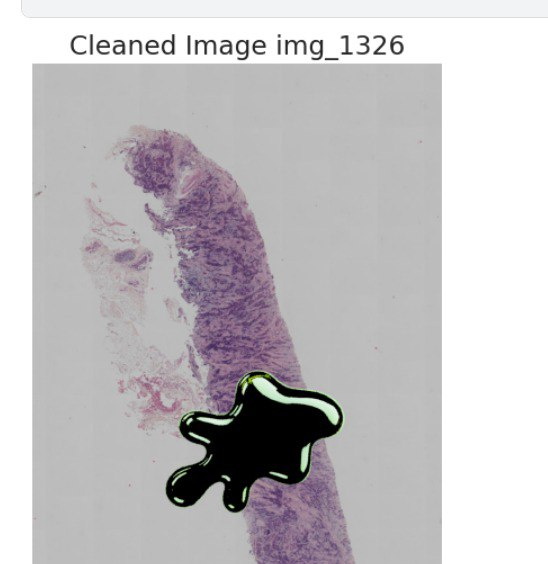

In [10]:
#finds some contour and cuts away little central area of the blobs

import cv2
import numpy as np
import os
from tqdm import tqdm

def clean_goo_by_contour(df, cleaned_dir="train_data_cleaned", cleaned_mask_dir="train_masks_cleaned"):
    """
    Removes green goo using contour detection. Everything inside detected green blobs
    will be set to black in the image and 0 in the mask.
    """
    os.makedirs(cleaned_dir, exist_ok=True)
    os.makedirs(cleaned_mask_dir, exist_ok=True)

    cleaned_img_paths = []
    cleaned_mask_paths = []

    for img_path, mask_path in tqdm(zip(df['image_path'], df['mask_path']), total=len(df), desc="Cleaning goo by contour"):
        # Load image and mask
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        # Convert to HSV and threshold green
        hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
        lower_green = np.array([50, 80, 80])   # adjust if needed
        upper_green = np.array([90, 255, 255])
        green_mask = cv2.inRange(hsv, lower_green, upper_green)

        # Optional: close small holes in green mask
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7,7))
        green_mask = cv2.morphologyEx(green_mask, cv2.MORPH_CLOSE, kernel)

        # Find contours of green regions
        contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Fill the contours in image and mask
        cv2.drawContours(img_rgb, contours, -1, (0,0,0), thickness=cv2.FILLED)
        cv2.drawContours(mask, contours, -1, 0, thickness=cv2.FILLED)

        # Save cleaned image and mask
        base_name = os.path.basename(img_path)
        cleaned_img_path = os.path.join(cleaned_dir, base_name)
        cleaned_mask_path = os.path.join(cleaned_mask_dir, base_name)

        cv2.imwrite(cleaned_img_path, cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
        cv2.imwrite(cleaned_mask_path, mask)

        cleaned_img_paths.append(cleaned_img_path)
        cleaned_mask_paths.append(cleaned_mask_path)

    # Update DataFrame
    df_cleaned = df.copy()
    df_cleaned['image_path'] = cleaned_img_paths
    df_cleaned['mask_path'] = cleaned_mask_paths

    return df_cleaned
    


the code above produces.

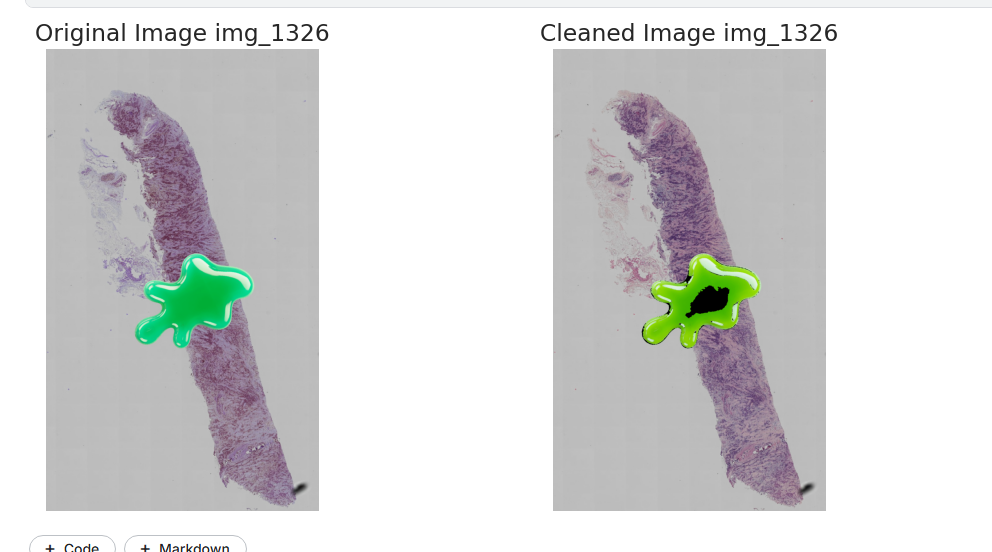

In [11]:
import cv2
import numpy as np
import os
from tqdm import tqdm
import pandas as pd

# The optimized HSV bounds based on the Shrek color palette (H=26 to H=90)
# These values are set to specifically target the yellow-browns and greens
# while avoiding the pink/red H&E stain.
LOWER_GREEN_HSV = np.array([26, 5, 5]) 
UPPER_GREEN_HSV = np.array([90, 255, 255])

def clean_goo_by_contour_inpainting(df, cleaned_dir="./train_data_cleaned", cleaned_mask_dir="./train_masks_cleaned"):
    """
    Removes green/yellow goo by identifying its outer contour and marking 
    the entire enclosed area for inpainting, thus removing the whole blob 
    including internal shades and highlights.

    Args:
        df (pd.DataFrame): DataFrame containing 'image_path' and 'mask_path'.
        cleaned_dir (str): Directory to save cleaned images.
        cleaned_mask_dir (str): Directory to save updated masks.
    """
    os.makedirs(cleaned_dir, exist_ok=True)
    os.makedirs(cleaned_mask_dir, exist_ok=True)

    cleaned_img_paths = []
    cleaned_mask_paths = []

    for img_path, mask_path in tqdm(zip(df['image_path'], df['mask_path']), total=len(df), desc="Precise green goo cleaning and inpainting"):
        # We read the image and mask
        img = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        if img is None or mask is None:
            print(f"Skipping missing image or mask: {os.path.basename(img_path)}")
            continue

        # Convert to HSV (using BGR since OpenCV reads files in BGR by default)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

        # 1. Green mask threshold (using optimized palette bounds)
        # This initial mask is only used to find the contours (outer boundaries) of the goo.
        green_mask = cv2.inRange(hsv, LOWER_GREEN_HSV, UPPER_GREEN_HSV)

        # 2. Morphological closing to smooth the goo boundary
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
        green_mask = cv2.morphologyEx(green_mask, cv2.MORPH_CLOSE, kernel)

        # 3. Find contours of the green blobs
        contours, _ = cv2.findContours(green_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # The mask used for inpainting must be a single 8-bit mask (0 or 255)
        inpaint_mask = np.zeros_like(green_mask, dtype=np.uint8)

        # 4. Iterate contours to build the final removal mask
        for cnt in contours:
            # Create a contour mask that fills the entire area enclosed by the green blob's outline
            contour_area_mask = np.zeros_like(green_mask, dtype=np.uint8)
            
            # Draw the filled contour based on the detected green boundary.
            cv2.drawContours(contour_area_mask, [cnt], -1, 255, thickness=cv2.FILLED)

            # CRITICAL MODIFICATION: Mark the entire area inside the contour for removal.
            # This handles internal shades, highlights, or non-green parts of the contamination.
            inpaint_mask[contour_area_mask > 0] = 255

        # 5. Apply Inpainting (only if contamination exists)
        if np.count_nonzero(inpaint_mask) > 0:
            # Use INPAINT_TELEA to reconstruct the background/tissue texture
            # This step fills the hole using surrounding healthy tissue pixels.
            img = cv2.inpaint(img, inpaint_mask, 3, cv2.INPAINT_TELEA) 
        
        # 6. Update tissue mask (mask)
        # We set the area where goo was removed to 0 (background) in the tissue mask.
        mask[inpaint_mask > 0] = 0

        # 7. Save cleaned image and mask
        base_name = os.path.basename(img_path)
        cleaned_img_path = os.path.join(cleaned_dir, base_name)
        # Ensure we correctly name the mask file based on convention
        cleaned_mask_path = os.path.join(cleaned_mask_dir, base_name.replace("img_", "mask_"))
        
        cv2.imwrite(cleaned_img_path, img) # img is still BGR
        cv2.imwrite(cleaned_mask_path, mask)

        cleaned_img_paths.append(cleaned_img_path)
        cleaned_mask_paths.append(cleaned_mask_path)

    df_cleaned = df.copy()
    df_cleaned['image_path'] = cleaned_img_paths
    df_cleaned['mask_path'] = cleaned_mask_paths

    return df_cleaned

the code above produces:

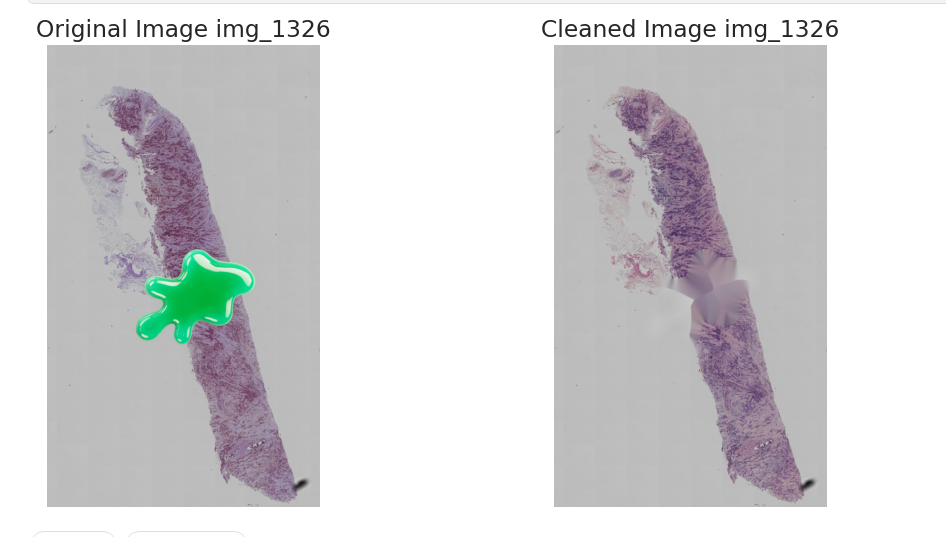
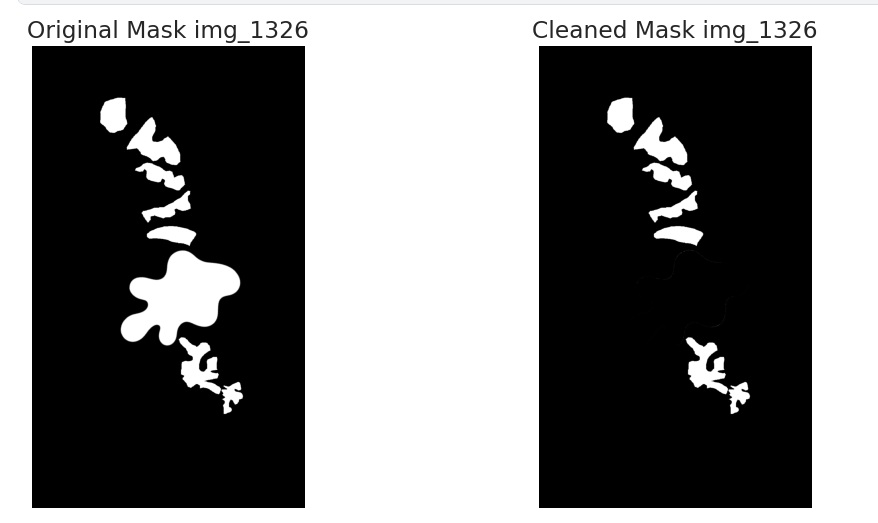

# MAIN

In [12]:
labels_df = pd.read_csv("/kaggle/input/an2dl-challenge2/an2dl/train_labels.csv")
labels_df.head()

,sample_index,label
0,img_0000.png,Triple negative
1,img_0001.png,Luminal A
2,img_0002.png,Luminal A
3,img_0003.png,Luminal B
4,img_0004.png,HER2(+)


In [13]:
print("ciao")

ciao


In [14]:
df_full = get_clean_dataframe(data_root="/kaggle/input/an2dl-challenge2/an2dl/")
df_no_shrek = remove_shrek(df_full)

#save_noshrek_dataset(df_noshrek, output_root="train_noshrek")

#worked well for green pixels, but the goo is not uniform. we need to remove contour wise
# df_cleaned = clean_green_goo_with_mask(
#     df_no_shrek,
#     cleaned_dir="../working/train_data_cleaned/",
#     cleaned_mask_dir="../working/train_masks_cleaned/"
# )
df_cleaned_contour = clean_goo_by_contour_inpainting(
    df_no_shrek,
    cleaned_dir="../working/train_data_cleaned_contour/",
    cleaned_mask_dir="../working/train_masks_cleaned_contour/"
)


Successfully merged 1412 images with their labels.

--- Manual Shrek Removal ---
Rows before: 1412
Rows after:  1278
Shrek removed: 134
----------------------------



Precise green goo cleaning and inpainting: 100%|██████████| 1278/1278 [11:45<00:00,  1.81it/s]


In [110]:
import pandas as pd


# oppure, meglio:
df_cleaned_contour.to_parquet("../working/df_cleaned_contour.parquet", index=False)


In [15]:
print("Shape:", df_no_shrek.shape)
print("\nColumns:", df_no_shrek.columns.tolist())

print("\nDataFrame Info:")
print(df_no_shrek.info())

print("\nFirst 10 rows:")
print(df_no_shrek.head(10))


Shape: (1278, 4)

Columns: ['sample_index', 'image_path', 'mask_path', 'label']

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1278 entries, 662 to 978
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   sample_index  1278 non-null   int64 
 1   image_path    1278 non-null   object
 2   mask_path     1278 non-null   object
 3   label         1278 non-null   object
dtypes: int64(1), object(3)
memory usage: 49.9+ KB
None

First 10 rows:
      sample_index                                         image_path  \
662              0  /kaggle/input/an2dl-challenge2/an2dl/train_dat...   
1164             1  /kaggle/input/an2dl-challenge2/an2dl/train_dat...   
1355             2  /kaggle/input/an2dl-challenge2/an2dl/train_dat...   
64               3  /kaggle/input/an2dl-challenge2/an2dl/train_dat...   
933              4  /kaggle/input/an2dl-challenge2/an2dl/train_dat...   
269              5  /kaggle/input/an2dl

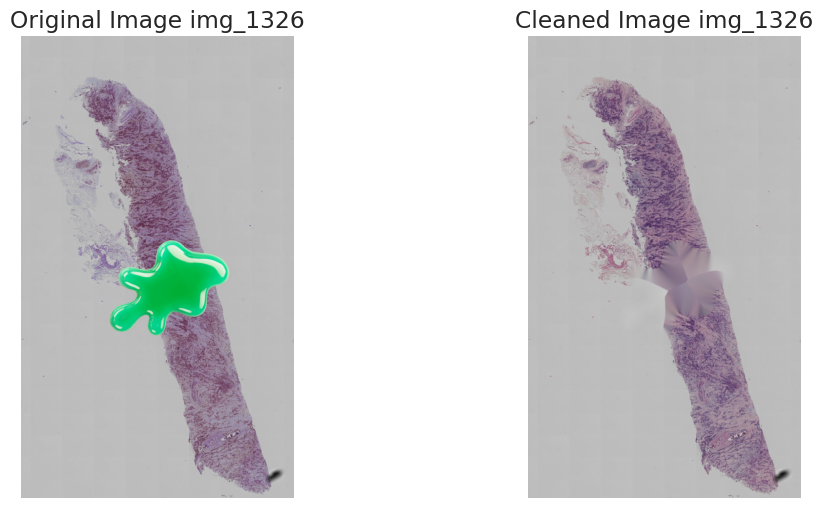

In [16]:
# --- Get original mask from df_no_shrek ---
row_original = df_no_shrek[df_no_shrek['sample_index'] == 1326].iloc[0]
original_img_path = row_original['image_path']
original_img = cv2.imread(original_img_path, cv2.COLOR_BGR2RGB)


# Example to visualize cleaned image
row = df_cleaned_contour[df_cleaned_contour['sample_index'] == 1326].iloc[0]
img = cv2.imread(row['image_path'])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(original_img)
plt.title("Original Image img_1326")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_rgb)
plt.axis('off')
plt.title("Cleaned Image img_1326")
plt.show()


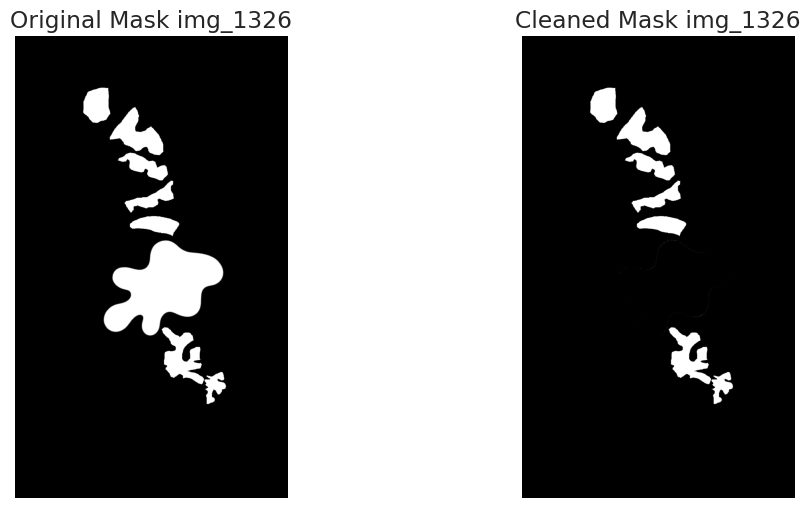

In [17]:
import cv2
import matplotlib.pyplot as plt

# --- Get original mask from df_no_shrek ---
row_original = df_no_shrek[df_no_shrek['sample_index'] == 1326].iloc[0]
original_mask_path = row_original['mask_path']
original_mask = cv2.imread(original_mask_path, cv2.IMREAD_GRAYSCALE)

# --- Get cleaned mask from df_cleaned ---
row_cleaned = df_cleaned_contour[df_cleaned_contour['sample_index'] == 1326].iloc[0]
cleaned_mask_path = row_cleaned['mask_path']
cleaned_mask = cv2.imread(cleaned_mask_path, cv2.IMREAD_GRAYSCALE)

# --- Plot side by side ---
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(original_mask, cmap='gray')
plt.title("Original Mask img_1326")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(cleaned_mask, cmap='gray')
plt.title("Cleaned Mask img_1326")
plt.axis('off')

plt.show()


Total images available in dataset: 1278
Displaying 4 selected images: [102, 108, 152, 153]


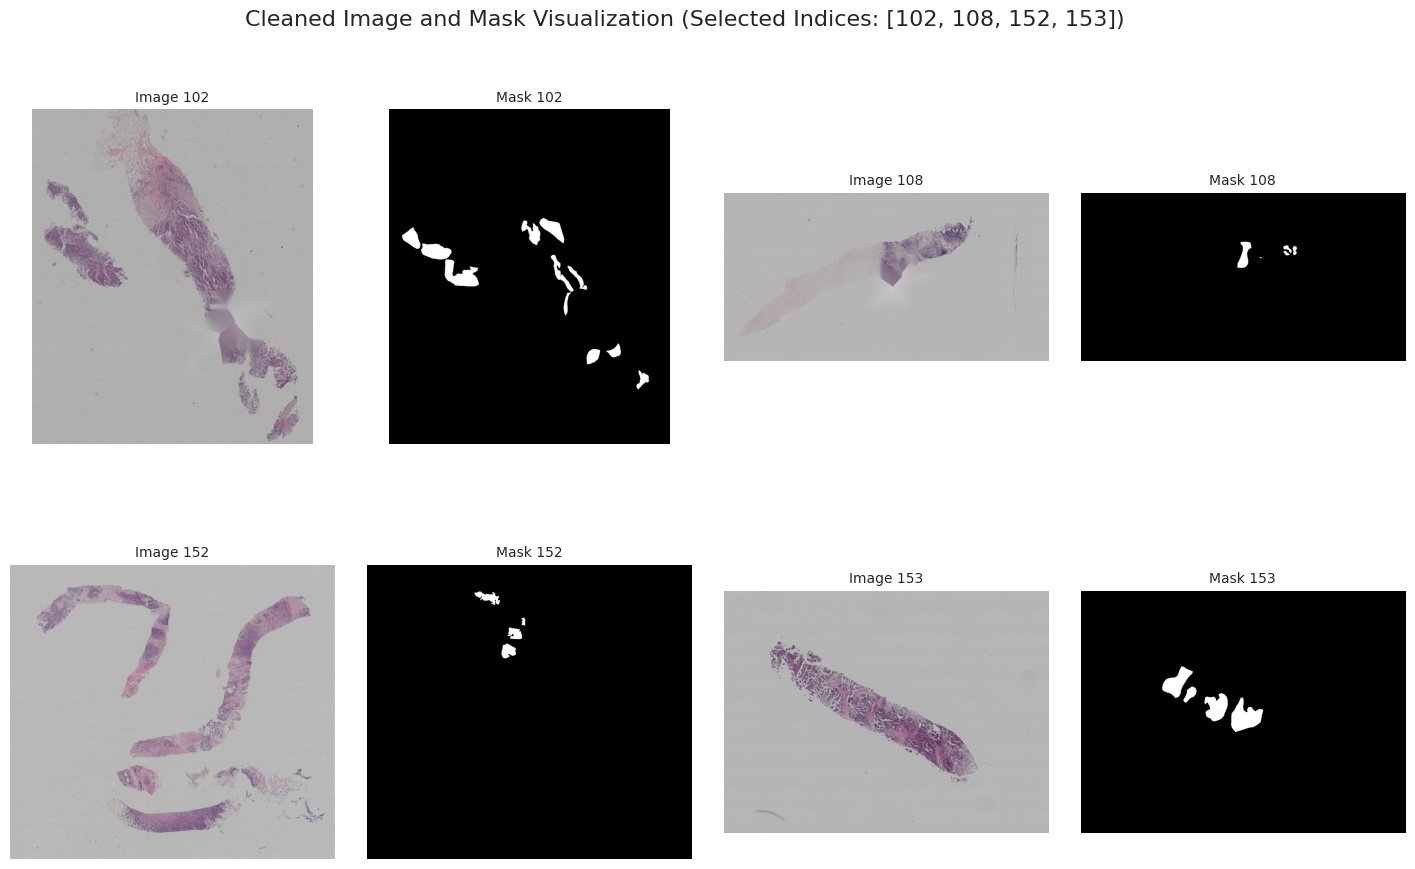

In [18]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# --- CONFIGURATION: Define the exact indices you want to inspect ---
# We will assume you meant the unique indices: 102, 108, 152, 153 (4 images total)
IMAGES_TO_VIEW = [102, 108, 152, 153]
# -----------------------------------------------------------------

# --- MOCK DATA SETUP ---
# NOTE: This section is kept to allow the script to run even if 'df_cleaned_contour' is not defined.
try:
    # Use the actual DataFrame passed from the contour cleaning function
    all_image_paths = df_cleaned_contour['image_path'].tolist()
    all_mask_paths = df_cleaned_contour['mask_path'].tolist()
    n_total_images = len(all_image_paths)
except NameError:
    print("Warning: 'df_cleaned_contour' not found. Using mock data paths for visualization test.")
    # Fallback to creating a mock DataFrame with enough paths to cover requested indices.
    MOCK_DIR = "./mock_data"
    os.makedirs(MOCK_DIR, exist_ok=True)
    
    # Ensure mock count covers the highest requested index + 1
    MOCK_COUNT = max(IMAGES_TO_VIEW) + 1 
    all_image_paths = [f"{MOCK_DIR}/img_{i}.png" for i in range(MOCK_COUNT)]
    all_mask_paths = [f"{MOCK_DIR}/mask_{i}.png" for i in range(MOCK_COUNT)]
    n_total_images = MOCK_COUNT
    
    # Create simple mock images if they don't exist (for full runnability)
    for p in all_image_paths + all_mask_paths:
        if not os.path.exists(p):
            mock_img = np.zeros((100, 100, 3), dtype=np.uint8)
            cv2.imwrite(p, mock_img)
# --- END MOCK DATA SETUP ---


n_images_to_show = len(IMAGES_TO_VIEW)
n_rows = int(np.ceil(n_images_to_show / 2.0)) # Max 2 pairs per row
n_cols = 4 # Fixed layout: Image | Mask || Image | Mask (4 columns)

print(f"Total images available in dataset: {n_total_images}")
print(f"Displaying {n_images_to_show} selected images: {IMAGES_TO_VIEW}")

# Figure and axes: dynamic rows (1 or 2), 4 columns
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
plt.subplots_adjust(wspace=0.1, hspace=0.3)
fig.suptitle(f"Cleaned Image and Mask Visualization (Selected Indices: {IMAGES_TO_VIEW})", fontsize=16)

# Flatten the axes array for easier indexing, handle case where n_rows=1
if n_rows == 1:
    axes = np.array([axes]).flatten()
else:
    axes = axes.flatten()

# This tracks the index within the IMAGES_TO_VIEW array (0 to 3)
for plot_idx, global_img_idx in enumerate(IMAGES_TO_VIEW):
    
    if global_img_idx >= n_total_images:
        print(f"Skipping index {global_img_idx}: Index out of bounds (max index is {n_total_images - 1}).")
        continue

    # Determine the visual row (0 or 1)
    row = plot_idx // 2 
    # Determine if it's the left pair (0) or right pair (1)
    pair_index_in_row = plot_idx % 2 

    # Calculate image column (0 or 2) and mask column (1 or 3)
    col_img = pair_index_in_row * 2
    col_mask = pair_index_in_row * 2 + 1

    # Calculate index in the flattened axes array:
    ax_img_idx = row * n_cols + col_img
    ax_mask_idx = row * n_cols + col_mask
    
    # Get the specific axes objects
    ax_img = axes[ax_img_idx]
    ax_mask = axes[ax_mask_idx]

    try:
        # Load image and mask
        # Note: We must access the original list of paths using the global_img_idx
        img = cv2.cvtColor(cv2.imread(all_image_paths[global_img_idx]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(all_mask_paths[global_img_idx], cv2.IMREAD_GRAYSCALE)

        # Plot Image
        ax_img.imshow(img)
        ax_img.set_title(f"Image {global_img_idx}", fontsize=10)
        ax_img.axis('off')
        ax_img.set_aspect('equal')

        # Plot Mask
        ax_mask.imshow(mask, cmap='gray')
        ax_mask.set_title(f"Mask {global_img_idx}", fontsize=10)
        ax_mask.axis('off')
        ax_mask.set_aspect('equal')
        
    except Exception as e:
        ax_img.set_title(f"Error loading {global_img_idx}", fontsize=10)
        ax_mask.set_title(f"Error loading {global_img_idx}", fontsize=10)
        print(f"Could not load image {global_img_idx} at {all_image_paths[global_img_idx]}: {e}")
        
# Clear any unused axes slots
plots_used = n_images_to_show * 2
for j in range(plots_used, len(axes)):
    axes[j].remove()

plt.show()

---

# TRAINING

In [6]:
import pandas as pd

df_cleaned_contour = pd.read_parquet("/kaggle/input/df-cleaned-contour/df_cleaned_contour.parquet")

In [25]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from sklearn.metrics import f1_score
import numpy as np
import copy
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader

# Configurazione Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- A. DEFINIZIONE MODELLO (SAFE MODE) ---
def get_safe_model(num_classes):
    print("Caricamento EfficientNet-B0 (Backbone Congelata)...")
    # Carica pesi ImageNet
    model = models.efficientnet_b0(weights='DEFAULT')
    
    # FREEZE: Congela TUTTI i parametri della rete
    for param in model.parameters():
        param.requires_grad = False
        
    # Sostituisci la testa (Classification Head)
    # I nuovi layer creati qui hanno requires_grad=True di default
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3), # Dropout per ridurre overfitting
        nn.Linear(in_features, num_classes)
    )
    
    return model

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    return epoch_loss, epoch_f1


def train_one_epoch(model, loader, criterion, optimizer, scaler=None):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # SINTASSI AGGIORNATA: torch.amp.autocast('cuda')
        if scaler:
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        
    epoch_loss = running_loss / len(loader.dataset)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')
    return epoch_loss, epoch_f1

def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scheduler=None, patience=5, save_path='best_model.pth'):
    # Inizializzazione storico
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_f1 = 0.0
    patience_counter = 0
    
    # Scaler per Mixed Precision (gestisce automaticamente CUDA se disponibile)
    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None
    
    print(f"Inizio Training per {epochs} epoche...")
    
    for epoch in range(epochs):
        # Training
        train_loss, train_f1 = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        
        # Validation
        val_loss, val_f1 = validate(model, val_loader, criterion)
        
        # Scheduler Step
        if scheduler:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_f1)
            else:
                scheduler.step()
        
        # Salvataggio metriche
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_f1'].append(train_f1)
        history['val_f1'].append(val_f1)
        
        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f}, F1: {train_f1:.4f} | "
              f"Val Loss: {val_loss:.4f}, F1: {val_f1:.4f}")
        
        # Checkpoint & Early Stopping
        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), save_path)
            print(f"  --> Nuova Best F1! Modello salvato in {save_path}")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\nEarly Stopping attivato all'epoca {epoch+1}.")
                break
                
    # Carica i pesi migliori prima di uscire
    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path))
        print("Pesi migliori ricaricati.")
        
    return history

In [26]:
from torchvision import models
import torch.nn as nn

def get_robust_transfer_model(num_classes):
    print("Caricamento EfficientNet-B0 Pre-trained...")
    model = models.efficientnet_b0(weights='DEFAULT')
    
    # 1. Congelamento Base
    for param in model.parameters():
        param.requires_grad = False
        
    # 2. Fine-Tuning Selettivo (Ultimi 3 blocchi)
    # Adatta le feature di alto livello al dominio istologico
    for param in model.features[6:].parameters():
        param.requires_grad = True
        
    # 3. Testa Robusta
    # Recuperiamo dinamicamente la dimensione di input (1280 per B0)
    in_features = model.classifier[1].in_features
    
    model.classifier = nn.Sequential(
        nn.Dropout(0.6),            # Dropout aggressivo in ingresso
        nn.Linear(in_features, 512), # Usa la variabile, non il numero fisso
        nn.ReLU(),
        nn.Dropout(0.5),            # Dropout standard prima dell'output
        nn.Linear(512, num_classes)
    )
    
    return model

model = get_robust_transfer_model(num_classes=4).to(device)

Caricamento EfficientNet-B0 Pre-trained...


In [91]:
import torch
from torch.utils.data import Dataset
from torchvision.transforms import v2
from PIL import Image
import numpy as np

class HistologyDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = np.array(list(image_paths))
        self.labels = np.array(list(labels))
        self.transform = transform

        if len(self.image_paths) == 0:
            raise ValueError("Errore: Dataset vuoto.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Errore file: {img_path}")
            raise e

        # Applicazione Trasformazione
        if self.transform:
            image = self.transform(image)
        else:
            image = v2.functional.to_image(image)
            image = v2.functional.to_dtype(image, torch.float32, scale=True)
            
        # --- FIX CRITICO PER V2 ---
        # Se l'immagine è un tv_tensors.Image (output di v2), 
        # il DataLoader potrebbe non riuscire a farne lo stack.
        # Lo convertiamo forzatamente in un Tensor PyTorch puro.
        if isinstance(image, torch.Tensor):
            image = image.as_subclass(torch.Tensor)
            
        return image, label

In [84]:
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    df_cleaned_contour.image_path, df_cleaned_contour.label, test_size=0.2, random_state=42
)

In [95]:
from sklearn.preprocessing import LabelEncoder

# 1. Istanzia l'encoder
le = LabelEncoder()

# 2. Fit e Transform sul Training Set
# Impara il vocabolario dai dati di training e converte
y_train_int = le.fit_transform(y_train)

# 3. Solo Transform sul Validation Set
# IMPORTANTE: Usare .transform(), NON .fit_transform()
# Questo garantisce che usi la stessa mappatura appresa al punto 2.
# Se in val c'è una classe mai vista nel train, questo solleverà un errore (giustamente).
y_val_int = le.transform(y_val)

# 4. Verifica della Mappatura (Essenziale per la submission)
# Stampa l'associazione per capire a cosa corrispondono 0, 1, 2, 3
print("Mappatura Classi:", dict(zip(le.transform(le.classes_), le.classes_)))

Mappatura Classi: {0: 'HER2(+)', 1: 'Luminal A', 2: 'Luminal B', 3: 'Triple negative'}


In [86]:
from torch.utils.data import WeightedRandomSampler
from torch.utils.data import DataLoader
import numpy as np
import torch

def get_sampler(labels):
    """
    Crea un WeightedRandomSampler per bilanciare le classi nel DataLoader.
    """
    # Conta le occorrenze di ogni classe
    class_counts = np.bincount(labels)
    
    # Calcola il peso inverso (classi rare -> peso alto)
    class_weights = 1. / class_counts
    
    # Assegna un peso ad ogni singolo sample nel dataset in base alla sua label
    sample_weights = [class_weights[label] for label in labels]
    
    # Crea il sampler
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True # Fondamentale: permette di ripescare le classi rare
    )
    return sampler

In [93]:
sampler = get_sampler(y_train_int)

---

In [96]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision.transforms import v2

# --- 1. NUOVA AUGMENTATION (Color Jitter) ---
train_transform_robust = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomResizedCrop(size=(224, 224), scale=(0.5, 1.0)), # Zoom più contenuto
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    # Jitter: Varia luminosità, contrasto e saturazione. Cruciale per H&E.
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.02),
    v2.RandomAffine(degrees=15, translate=(0.1, 0.1)), # Piccole rotazioni
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize(size=(224, 224)),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# Ricrea il dataset con la nuova trasformazione
train_dataset = HistologyDataset(X_train, y_train_int, transform=train_transform_robust)
# Val dataset resta uguale (solo resize/center crop)
val_dataset = HistologyDataset(X_val, y_val_int, transform=val_transforms) 

# Loader (Usa il sampler che hai già creato)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)


# --- 2. DEFINIZIONE FOCAL LOSS ---
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha # Può essere un tensore di pesi per classe
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss) # probabilità della classe corretta
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

# --- 3. SETUP MODELLO E TRAINING ---
model = get_robust_transfer_model(num_classes=4).to(device)

# Aumentiamo il Dropout nella testa (modifica manuale se get_robust... non lo fa)
model.classifier[0] = nn.Dropout(0.6) # Primo dropout
model.classifier[3] = nn.Dropout(0.5) # Secondo dropout

# Optimizer con Weight Decay più alto (0.01 invece di 1e-3 o 1e-4)
optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-6},   # Molto lento
    {'params': model.classifier.parameters(), 'lr': 1e-4}  # Lento
], weight_decay=0.01)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

criterion = FocalLoss(alpha=None, gamma=2.0) 

print("Riavvio training SENZA pesi alpha (gestiti dal Sampler)...")

# Rilancia il fit
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    patience=8,
    save_path='best_model_focal_corrected.pth'
)

Caricamento EfficientNet-B0 Pre-trained...
Riavvio training SENZA pesi alpha (gestiti dal Sampler)...
Inizio Training per 30 epoche...
Epoch 1/30 | Train Loss: 0.7876, F1: 0.2616 | Val Loss: 0.7935, F1: 0.1650
  --> Nuova Best F1! Modello salvato in best_model_focal_corrected.pth
Epoch 2/30 | Train Loss: 0.7973, F1: 0.2618 | Val Loss: 0.7890, F1: 0.2080
  --> Nuova Best F1! Modello salvato in best_model_focal_corrected.pth


KeyboardInterrupt: 

# Best model for now Public score: 0.3179

In [97]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.transforms import v2

# 1. Riduciamo l'intensità dell'Augmentation
# Meno distorsione colore, crop meno aggressivo
train_transform_light = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomResizedCrop(size=(224, 224), scale=(0.6, 1.0)), # Zoom meno spinto
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    # Jitter leggero: aiuta senza stravolgere
    v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.01),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
val_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize(size=(224, 224)),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# Riapplichiamo al dataset
train_dataset = HistologyDataset(X_train, y_train_int, transform=train_transform_light)
val_dataset = HistologyDataset(X_val, y_val_int, transform=val_transforms) 
# Loader (Manteniamo il Sampler, è l'unica cosa che DEVE restare)
train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)


# 2. Modello con MENO Dropout
def get_lighter_model(num_classes):
    print("Caricamento EfficientNet-B0 (Light Regularization)...")
    model = models.efficientnet_b0(weights='DEFAULT')
    
    # Scongeliamo gli ultimi blocchi (strategia corretta)
    for param in model.parameters():
        param.requires_grad = False
    for param in model.features[6:].parameters():
        param.requires_grad = True
        
    in_features = model.classifier[1].in_features
    
    # Testa semplificata: Dropout ridotto a 0.3
    model.classifier = nn.Sequential(
        nn.Dropout(0.3), 
        nn.Linear(in_features, 256), # Layer intermedio più compatto
        nn.ReLU(),
        nn.Dropout(0.2),
        nn.Linear(256, num_classes)
    )
    return model

model = get_lighter_model(num_classes=4).to(device)

# 3. Ritorno alla CrossEntropy standard
criterion = nn.CrossEntropyLoss() 

# 4. Optimizer con Weight Decay basso
optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 1e-4},   # LR più vivace per la backbone
    {'params': model.classifier.parameters(), 'lr': 1e-3}  # LR standard per la testa
], weight_decay=1e-4) # Regolarizzazione leggera

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

print("Avvio Training Semplificato (Obiettivo: Sbloccare l'apprendimento)...")
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=25,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    patience=6,
    save_path='best_model_light.pth'
)

Caricamento EfficientNet-B0 (Light Regularization)...
Avvio Training Semplificato (Obiettivo: Sbloccare l'apprendimento)...
Inizio Training per 25 epoche...


KeyboardInterrupt: 

# another one

In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.transforms import v2

# 1. TRASFORMAZIONI: Validazione più sicura
# Rimuoviamo CenterCrop dalla validazione per non perdere dettagli ai bordi.
# Training robusto per evitare memorizzazione.
train_transform_balanced = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0)), # Zoom moderato
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomAffine(degrees=15, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform_safe = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((224, 224)), # Resize intero (deforma ma non taglia)
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Applicazione
train_dataset = HistologyDataset(X_train, y_train_int, transform=train_transform_balanced)
val_dataset = HistologyDataset(X_val, y_val_int, transform=val_transform_safe)

train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

# 2. MODELLO: Regolarizzazione Media
def get_balanced_model(num_classes):
    print("Caricamento EfficientNet-B0 (Balanced Regularization)...")
    model = models.efficientnet_b0(weights='DEFAULT')
    
    # Scongeliamo gli ultimi blocchi
    for param in model.parameters():
        param.requires_grad = False
    for param in model.features[6:].parameters():
        param.requires_grad = True
        
    in_features = model.classifier[1].in_features
    
    # Dropout aumentato a 0.5 (Standard efficace)
    model.classifier = nn.Sequential(
        nn.Dropout(0.5), 
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model

model = get_balanced_model(num_classes=4).to(device)

# 3. LOSS: Label Smoothing
# Aiuta a prevenire l'overfitting penalizzando la troppa sicurezza (Overconfidence)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 

# 4. OPTIMIZER: Weight Decay Medio
# 1e-3 è un buon compromesso tra imparare (1e-4) e non memorizzare (1e-2)
optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 5e-5}, # LR basso per backbone
    {'params': model.classifier.parameters(), 'lr': 5e-4} # LR medio per testa
], weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

print("Avvio Training Bilanciato (Label Smoothing + Safe Val)...")
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=30,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    patience=8,
    save_path='best_model_balanced.pth'
)

Caricamento EfficientNet-B0 (Balanced Regularization)...
Avvio Training Bilanciato (Label Smoothing + Safe Val)...
Inizio Training per 30 epoche...


KeyboardInterrupt: 

# high res

In [98]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.transforms import v2
from torch.utils.data import DataLoader

# 1. TRASFORMAZIONI AD ALTA RISOLUZIONE
# Passiamo a 300x300.
NEW_SIZE = 300 

train_transform_hires = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.RandomResizedCrop(size=(NEW_SIZE, NEW_SIZE), scale=(0.6, 1.0)), 
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5), # Sempre utile in istologia
    v2.RandomAffine(degrees=20, translate=(0.1, 0.1)),
    v2.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.01),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform_hires = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Resize((NEW_SIZE, NEW_SIZE)), # Resize semplice a 300
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Applicazione Dataset
train_dataset = HistologyDataset(X_train, y_train_int, transform=train_transform_hires)
val_dataset = HistologyDataset(X_val, y_val_int, transform=val_transform_hires)

# RIDUCI BATCH SIZE per compensare la memoria
BATCH_SIZE = 16 
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


# 2. MODELLO "DEEP UNFREEZE"
def get_hires_model(num_classes):
    print(f"Caricamento EfficientNet-B0 (Input {NEW_SIZE}x{NEW_SIZE}, Deep Unfreeze)...")
    model = models.efficientnet_b0(weights='DEFAULT')
    
    # EfficientNet-B0 ha blocchi features[0]...features[8]
    # Strategia: Congeliamo solo l'inizio (0-3), sblocchiamo da metà (4-8) in poi.
    # Questo permette di adattare le feature di medio livello.
    
    for param in model.parameters():
        param.requires_grad = False
        
    # Scongeliamo dal blocco 4 alla fine
    for param in model.features[4:].parameters():
        param.requires_grad = True
        
    in_features = model.classifier[1].in_features
    
    # Testa bilanciata (quella che ha funzionato bene)
    model.classifier = nn.Sequential(
        nn.Dropout(0.5), 
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(256, num_classes)
    )
    return model

model = get_hires_model(num_classes=4).to(device)

# 3. CONFIGURAZIONE TRAINING
# Label Smoothing ha funzionato bene, lo manteniamo
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) 

optimizer = optim.AdamW([
    {'params': model.features.parameters(), 'lr': 3e-5}, # LR basso per la parte profonda
    {'params': model.classifier.parameters(), 'lr': 3e-4} # LR medio per la testa
], weight_decay=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

print(f"Avvio Training High-Res ({NEW_SIZE}px)...")
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=25,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    patience=5,
    save_path='best_model_hires.pth'
)

Caricamento EfficientNet-B0 (Input 300x300, Deep Unfreeze)...
Avvio Training High-Res (300px)...
Inizio Training per 25 epoche...
Epoch 1/25 | Train Loss: 1.3821, F1: 0.2736 | Val Loss: 1.4053, F1: 0.1406
  --> Nuova Best F1! Modello salvato in best_model_hires.pth
Epoch 2/25 | Train Loss: 1.3850, F1: 0.2782 | Val Loss: 1.3892, F1: 0.2526
  --> Nuova Best F1! Modello salvato in best_model_hires.pth
Epoch 3/25 | Train Loss: 1.3656, F1: 0.3032 | Val Loss: 1.3805, F1: 0.2868
  --> Nuova Best F1! Modello salvato in best_model_hires.pth
Epoch 4/25 | Train Loss: 1.3536, F1: 0.3374 | Val Loss: 1.3805, F1: 0.2975
  --> Nuova Best F1! Modello salvato in best_model_hires.pth
Epoch 5/25 | Train Loss: 1.3382, F1: 0.3337 | Val Loss: 1.3526, F1: 0.3484
  --> Nuova Best F1! Modello salvato in best_model_hires.pth
Epoch 6/25 | Train Loss: 1.3431, F1: 0.3429 | Val Loss: 1.3674, F1: 0.3205
Epoch 7/25 | Train Loss: 1.3155, F1: 0.3803 | Val Loss: 1.3557, F1: 0.3391
Epoch 8/25 | Train Loss: 1.2961, F1: 0.4

---

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_training_history(train_losses, val_losses, train_f1s, val_f1s):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(18, 6))
    
    # Grafico 1: Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Training Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Training & Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Grafico 2: F1 Score
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_f1s, 'b-', label='Training F1')
    plt.plot(epochs, val_f1s, 'r-', label='Validation F1')
    plt.title('Training & Validation F1-Score')
    plt.xlabel('Epochs')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

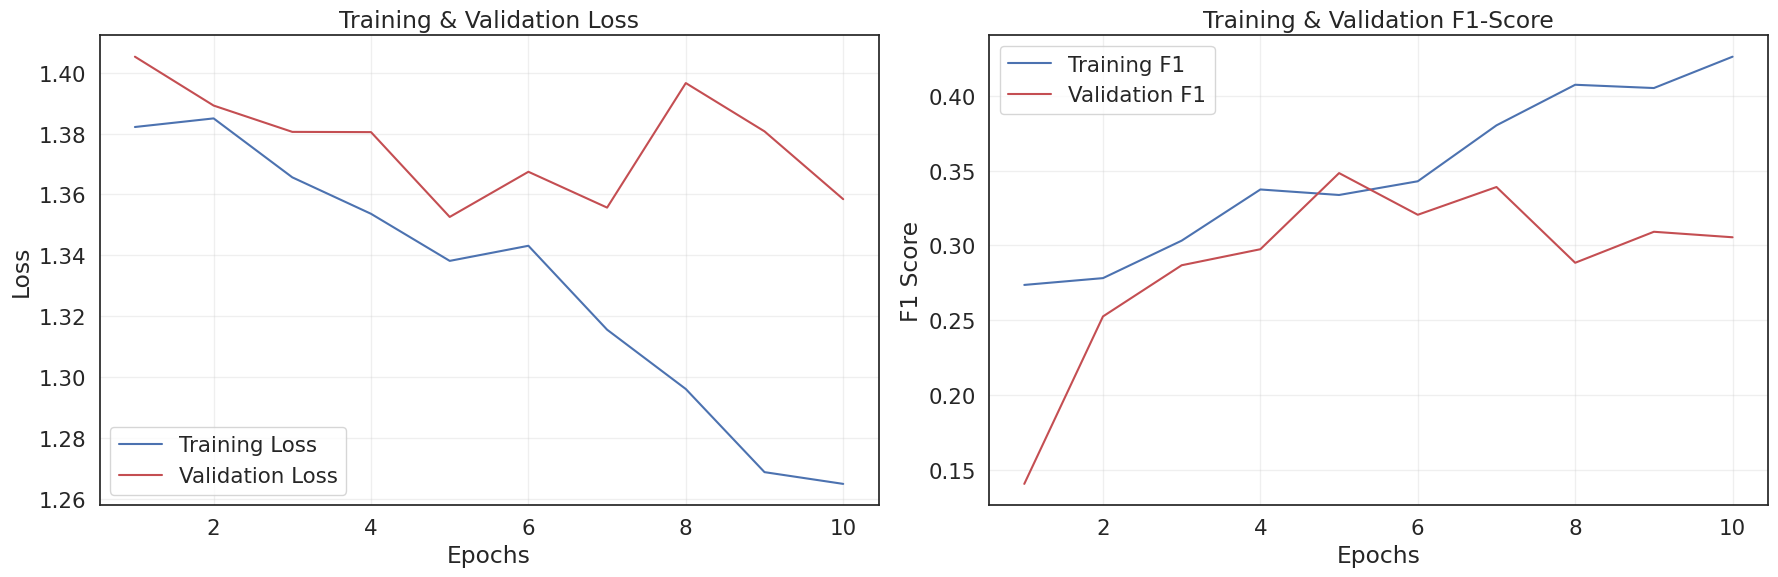

In [99]:
plot_training_history(history['train_loss'], history['val_loss'], history['train_f1'], history['val_f1'])

In [56]:
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import torch

def plot_confusion_matrix_and_f1(model, loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    
    # 1. Raccolta Predizioni
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    # 2. Calcolo F1-Score (Weighted)
    # 'weighted' tiene conto dello sbilanciamento delle classi
    val_f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"\n Validation F1-Score (Weighted): {val_f1:.4f}")
    
    # 3. Calcolo e Plot Matrice di Confusione
    cm = confusion_matrix(all_labels, all_preds)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix (F1: {val_f1:.4f})')
    plt.show()
    return val_f1



 Validation F1-Score (Weighted): 0.3484


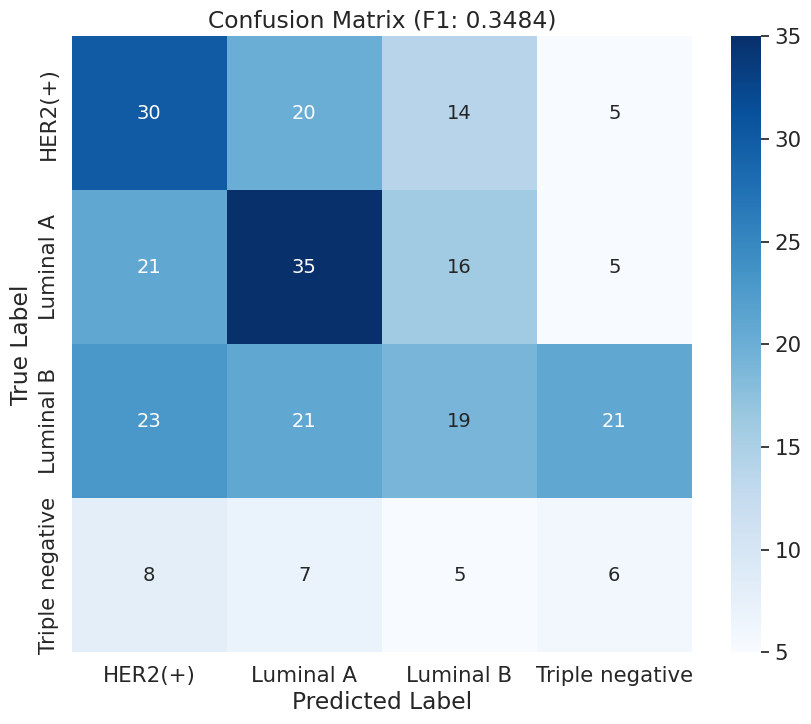

In [100]:

val_f1 = plot_confusion_matrix_and_f1(model, val_loader, device, le.classes_)

In [52]:
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize
from itertools import cycle

def plot_multiclass_roc_and_per_class_f1(model, loader, device, class_names):
    model.eval()
    y_test = []
    y_score = []
    
    # Raccolta probabilità e label
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1) # Importante: probabilità, non logits
            
            y_test.extend(labels.cpu().numpy())
            y_score.extend(probs.cpu().numpy())
            
    y_test = np.array(y_test)
    y_score = np.array(y_score)
    n_classes = len(class_names)
    
    # Binarizzazione label per ROC multiclasse
    y_test_bin = label_binarize(y_test, classes=range(n_classes))
    
    # --- Grafico 1: Curve ROC ---
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
    plt.figure(figsize=(20, 8))
    
    plt.subplot(1, 2, 1)
    colors = cycle(['blue', 'red', 'green', 'orange'])
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.2f})')
                 
    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curves')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    
    # --- Grafico 2: F1-Score per Classe ---
    plt.subplot(1, 2, 2)
    
    # Calcolo report
    y_pred = np.argmax(y_score, axis=1)
    report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
    
    # Estrazione F1 per classe (escludendo 'accuracy', 'macro avg', etc.)
    f1_scores = [report[cls]['f1-score'] for cls in class_names]
    
    sns.barplot(x=class_names, y=f1_scores, palette='viridis')
    plt.title('F1-Score per Class')
    plt.ylabel('F1 Score')
    plt.ylim(0, 1)
    for i, v in enumerate(f1_scores):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
        
    plt.tight_layout()
    plt.show()




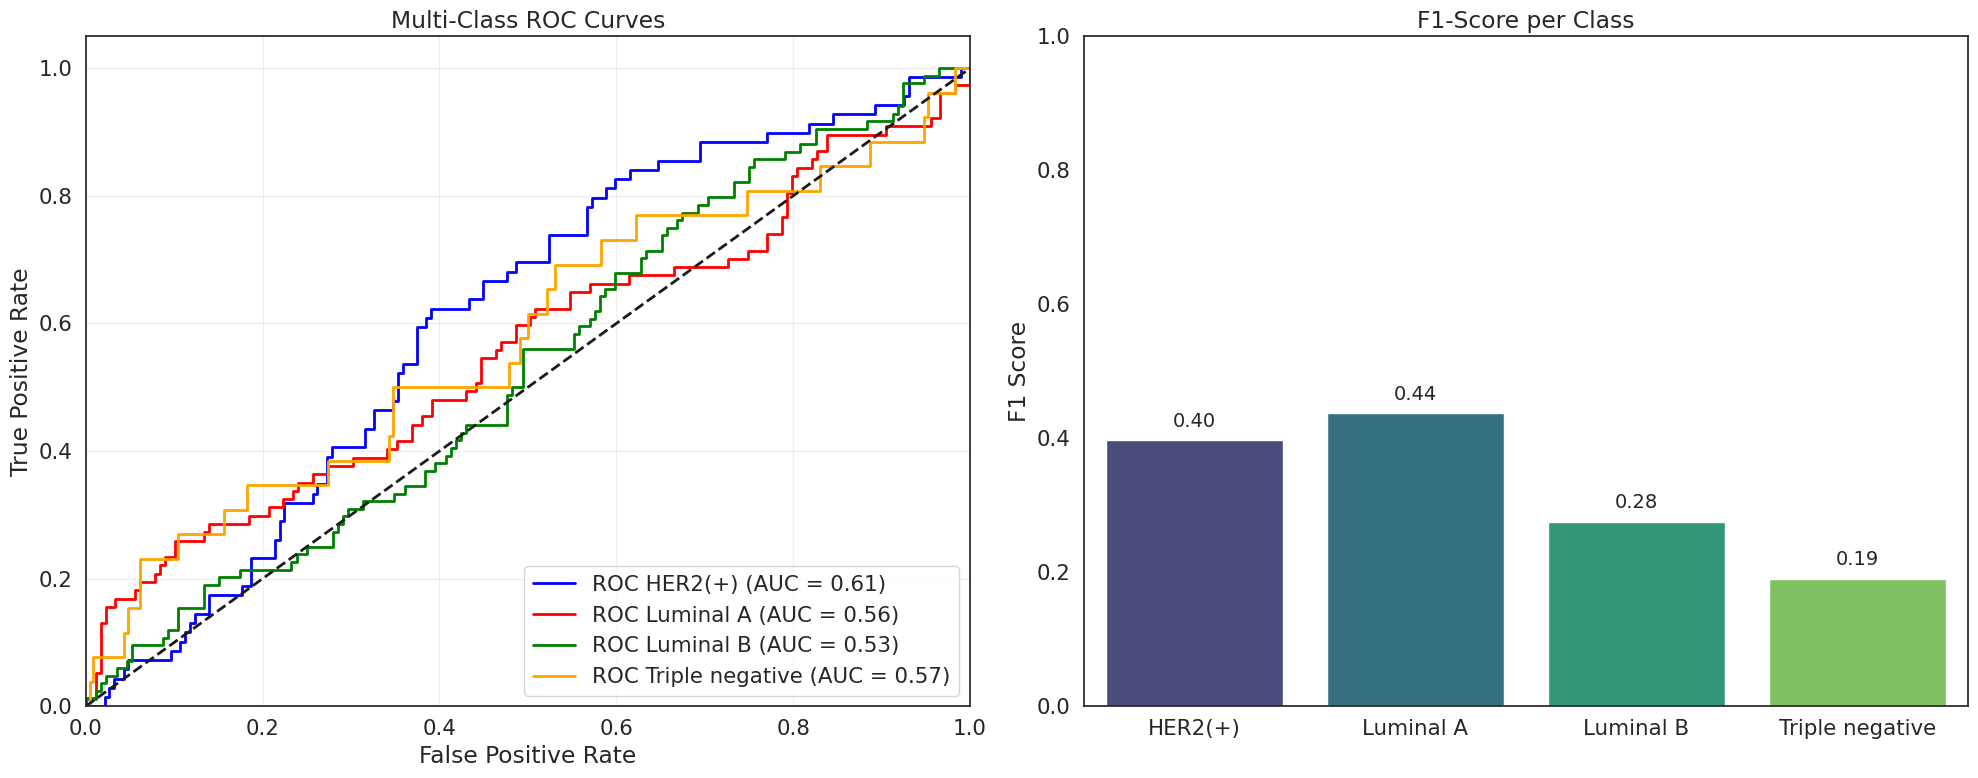

In [101]:
plot_multiclass_roc_and_per_class_f1(model, val_loader, device, le.classes_)

In [96]:
import csv
import os
import cv2
import torch
from torchvision.transforms import v2

def create_submission(model, label_encoder_obj, test_dir, output_file="submission.csv"):
    IMG_SIZE = 224 # Vincolo EfficientNet
    model.eval()
    
    # Filtra e ordina i file
    test_files = [f for f in os.listdir(test_dir) if f.startswith('img_') and f.endswith('.png')]
    # Ordina in base al numero estratto dal nome file
    test_files.sort(key=lambda x: int(x.split('_')[1].split('.')[0]))
    
    print(f"Generazione file sottomissione per {len(test_files)} immagini...")
    
    predictions = []
    
    with torch.no_grad():
        for i, filename in enumerate(test_files):
            img_path = os.path.join(test_dir, filename)
            
            img = cv2.imread(img_path)
            if img is None:
                continue
                
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            
            img_t = v2.functional.to_image(img)
            img_t = v2.functional.to_dtype(img_t, torch.float32, scale=True)
            img_t = v2.functional.normalize(img_t, 
                                            mean=[0.485, 0.456, 0.406], 
                                            std=[0.229, 0.224, 0.225])
            
            img_t = img_t.unsqueeze(0).to(device)
            
            outputs = model(img_t)
            _, predicted_idx = torch.max(outputs, 1)
            
            predicted_label = label_encoder_obj.inverse_transform([predicted_idx.item()])[0]
            
            # --- MODIFICA CRITICA QUI ---
            # La piattaforma richiede 'sample_index'.
            # A volte vuole il nome intero 'img_123.png', a volte solo '123'.
            # Se 'filename' fallisce, prova a sostituire con 'file_id' qui sotto.
            # file_id = filename.split('_')[1].split('.')[0] 
            
            predictions.append((filename, predicted_label))
            
            if (i + 1) % 100 == 0:
                print(f"Processati {i + 1}/{len(test_files)}")

    with open(output_file, mode='w', newline='') as f:
        writer = csv.writer(f)
        # HEADER CORRETTO: sample_index
        writer.writerow(['sample_index', 'label']) 
        writer.writerows(predictions)
        
    print(f"File '{output_file}' pronto.")

# Esecuzione
create_submission(model, le, TEST_DIR, 'AmazingSubmission.csv')

Generazione file sottomissione per 954 immagini...
Processati 100/954
Processati 200/954
Processati 300/954
Processati 400/954
Processati 500/954
Processati 600/954
Processati 700/954
Processati 800/954
Processati 900/954
File 'AmazingSubmission.csv' pronto.


---

In [102]:
import torch
import torch.nn.functional as F
import os
import cv2
import csv
from torchvision.transforms import v2

def create_submission_tta(model, label_encoder_obj, test_dir, output_file="submission_tta.csv"):
    # IMG_SIZE = 224
    IMG_SIZE = 300 # high res
    model.eval()
    
    test_files = [f for f in os.listdir(test_dir) if f.startswith('img_') and f.endswith('.png')]
    test_files.sort(key=lambda x: int(x.split('_')[1].split('.')[0]))
    
    print(f"Generazione TTA (5 view) su {len(test_files)} immagini...")
    
    # Definiamo diverse trasformazioni per la stessa immagine
    # 1. Base (Resize intero)
    t_base = v2.Compose([
        v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
        v2.Resize((IMG_SIZE, IMG_SIZE)),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 2. Flip Orizzontale
    t_flipH = v2.Compose([
        v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
        v2.Resize((IMG_SIZE, IMG_SIZE)),
        v2.RandomHorizontalFlip(p=1.0), # Forza il flip
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 3. Flip Verticale
    t_flipV = v2.Compose([
        v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
        v2.Resize((IMG_SIZE, IMG_SIZE)),
        v2.RandomVerticalFlip(p=1.0), # Forza il flip
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    # 4. Center Crop (Zoom centrale)
    '''t_center = v2.Compose([
        v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
        v2.Resize(256),
        v2.CenterCrop(224),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])'''

    t_center = v2.Compose([
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Resize(IMG_SIZE),
    v2.CenterCrop(IMG_SIZE),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])


    predictions = []
    
    with torch.no_grad():
        for i, filename in enumerate(test_files):
            img_path = os.path.join(test_dir, filename)
            img_orig = cv2.imread(img_path)
            if img_orig is None: continue
            img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
            
            # Creiamo il batch con le 4 varianti
            img_1 = t_base(img_orig)
            img_2 = t_flipH(img_orig)
            img_3 = t_flipV(img_orig)
            img_4 = t_center(img_orig)
            
            # Stack in un unico tensore [4, 3, 224, 224]
            batch = torch.stack([img_1, img_2, img_3, img_4]).to(device)
            
            # Inferenza su tutto il batch
            outputs = model(batch)
            
            # Applichiamo Softmax per avere probabilità
            probs = F.softmax(outputs, dim=1)
            
            # Media delle probabilità (Average Pooling delle previsioni)
            avg_probs = torch.mean(probs, dim=0)
            
            # Argmax sulla media
            predicted_idx = torch.argmax(avg_probs).item()
            predicted_label = label_encoder_obj.inverse_transform([predicted_idx])[0]
            
            predictions.append((filename, predicted_label))
            
            if (i + 1) % 100 == 0:
                print(f"Processati {i + 1}")

    with open(output_file, mode='w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['sample_index', 'label'])
        writer.writerows(predictions)
        
    print(f"✅ Submission TTA salvata in {output_file}")

# Esegui la TTA
create_submission_tta(model, le, "/kaggle/input/an2dl-challenge2/an2dl/test_data", f'submission_tta{val_f1:.4f}.csv')

Generazione TTA (5 view) su 954 immagini...
Processati 100
Processati 200
Processati 300
Processati 400
Processati 500
Processati 600
Processati 700
Processati 800
Processati 900
✅ Submission TTA salvata in submission_tta0.3484.csv


In [69]:
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import torch
import torch.nn as nn

def sanity_check_no_aug(model_ignored, X_data, y_data, device):
    print("SANITY CHECK V2: Dati Statici (No Augmentation)...")
    
    # 1. Trasformazione con RESIZE OBBLIGATORIO
    # Senza Resize, il DataLoader fallisce nel creare il batch (stack error)
    static_transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Resize((224, 224)),  # <--- FONDAMENTALE per il tuo dataset
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    # 2. Dataset ridotto (32 campioni)
    # Usa la classe HistologyDataset corretta definita nei passaggi precedenti
    subset_size = 32
    sanity_dataset = HistologyDataset(X_data[:subset_size], y_data[:subset_size], transform=static_transform)
    
    # Shuffle=False per riproducibilità totale in questo test
    sanity_loader = DataLoader(sanity_dataset, batch_size=subset_size, shuffle=False) 
    
    # 3. Reset Modello (MicroNet)
    model_test = MicroNet(num_classes=4).to(device)
    optimizer = torch.optim.Adam(model_test.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    
    # 4. Loop di Overfitting
    model_test.train()
    
    # Carichiamo il batch una sola volta fuori dal loop per efficienza nel sanity check
    images, labels = next(iter(sanity_loader))
    images, labels = images.to(device), labels.to(device)
    
    for epoch in range(50):
        optimizer.zero_grad()
        outputs = model_test(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, preds = torch.max(outputs, 1)
        acc = (preds == labels).float().mean().item()
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/50 | Loss: {loss.item():.4f} | Batch Accuracy: {acc:.2%}")
            
    if acc > 0.95:
        print("\nSUCCESSO: Overfitting riuscito.")
        print("Il caricamento dati e le label sono allineati correttamente.")
    else:
        print("\nFALLIMENTO: Il modello non converge.")
        print("Possibile mismatch X-y o problemi nel calcolo del gradiente.")

# ESECUZIONE
# Usiamo X_train e y_train che sono stati definiti dal train_test_split
sanity_check_no_aug(None, X_train, y_train, device)

SANITY CHECK V2: Dati Statici (No Augmentation)...
Epoch 10/50 | Loss: 1.3349 | Batch Accuracy: 34.38%
Epoch 20/50 | Loss: 1.2371 | Batch Accuracy: 43.75%
Epoch 30/50 | Loss: 1.0762 | Batch Accuracy: 56.25%
Epoch 40/50 | Loss: 0.9218 | Batch Accuracy: 65.62%
Epoch 50/50 | Loss: 0.7704 | Batch Accuracy: 71.88%

FALLIMENTO: Il modello non converge.
Possibile mismatch X-y o problemi nel calcolo del gradiente.
